Problems: Categorical and Numerical Variables
---

In [59]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt


### Q1: 

part a. 

In [13]:
#  Represent these data as a matrix of one hot encoded variables
data = ['red', 'blue', 'blue', 'red', 'green', 'grey'] 
data_matrix = pd.get_dummies(data, dtype=int)
data_matrix.index = ['red', 'blue', 'blue', 'red', 'green', 'grey']
data_matrix.index.name = 'color'
data_matrix

,blue,green,grey,red
color,,,,
red,0,0,0,1
blue,1,0,0,0
blue,1,0,0,0
red,0,0,0,1
green,0,1,0,0
grey,0,0,1,0


part b.

In [14]:
#  Compute the sample proportions for each label
data_matrix.mean()

blue     0.333333
green    0.166667
grey     0.166667
red      0.333333
dtype: float64

part c.

<Axes: ylabel='Proportion'>

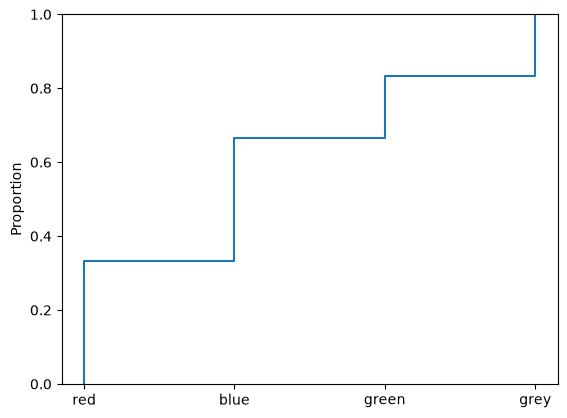

In [18]:
# Compute and sketch the empirical CDF for this sample
# sample list from the beginning, not one hot encoding
sns.ecdfplot(data=data)

### Q2.

part a.

![alt text](IMG_5670.jpeg)

part b.

In [23]:
x = np.array([1,3,4])
x
x.mean()

np.float64(2.6666666666666665)

part c.

In [25]:
x_squared = np.square(x)
x_squared.mean()

np.float64(8.666666666666666)

part d.

In [27]:
np.square(x.mean())
# This does not equal the mean from part c
# Non-linear transformations change the moments/stats of the data in a non-linear way

np.float64(7.111111111111111)

### Q3.

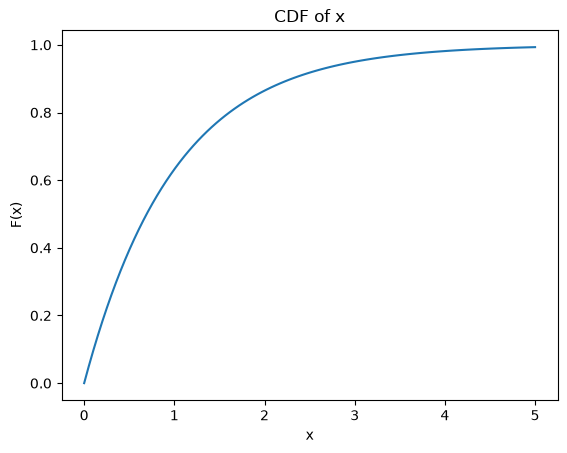

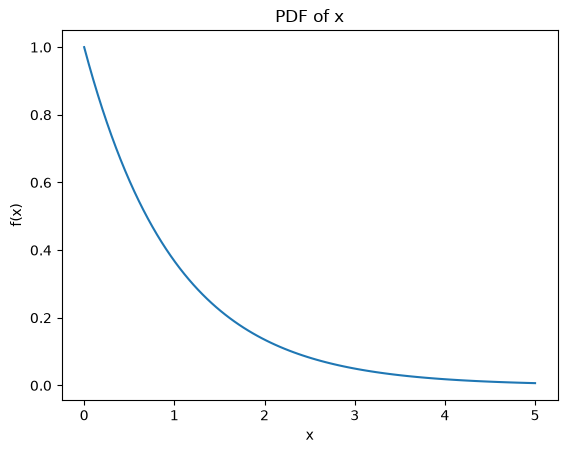

In [39]:
x = np.linspace(0, 5, 100)

# CDF: F(x) = 1-e^-x
# PDF : f(x) = F'(x) = e^-x
cdf = 1 - np.exp(-x)
pdf = np.exp(-x)

#plot
sns.lineplot(x=x, y=cdf)
plt.xlabel("x")
plt.ylabel("F(x)")
plt.title("CDF of x")
plt.show()

sns.lineplot(x=x, y=pdf)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("PDF of x")
plt.show()

part b.

![alt text](IMG_5671.jpeg)

part c.

![alt text](IMG_5672.jpeg)

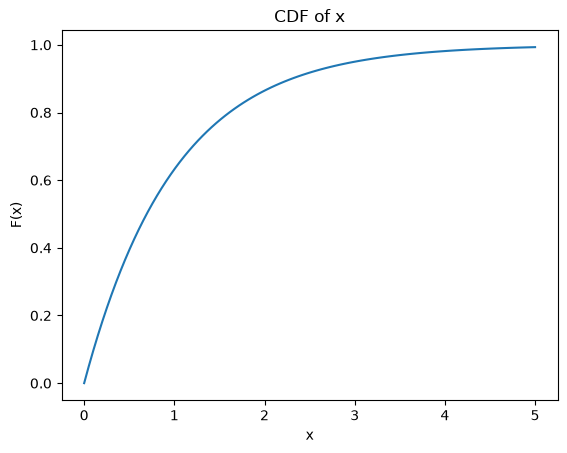

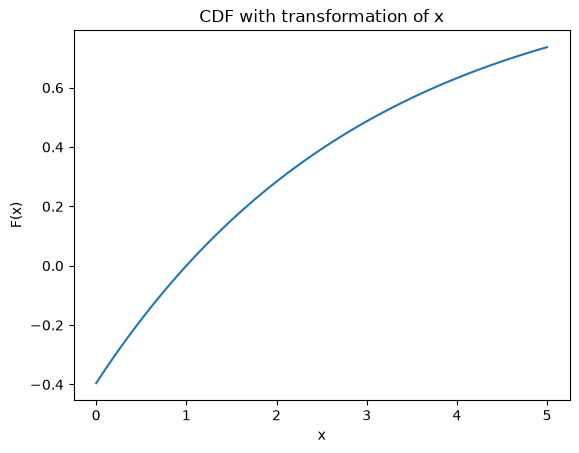

In [44]:
sns.lineplot(x=x, y=cdf)
plt.xlabel("x")
plt.ylabel("F(x)")
plt.title("CDF of x")
plt.show()

y = x.copy()
new_y = 1-np.exp(-(y-1)/3)
sns.lineplot(x=x, y= new_y)
plt.xlabel("x")
plt.ylabel("F(x)")
plt.title("CDF with transformation of x")
plt.show()

### Q4.

part a.

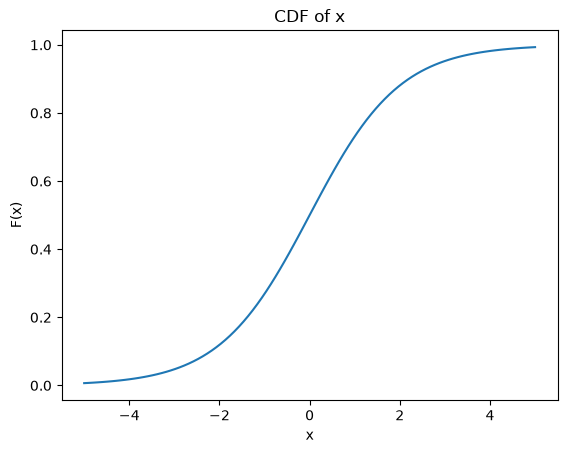

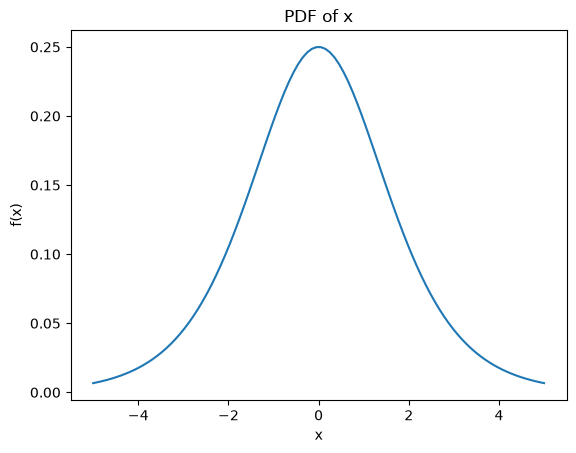

In [55]:
x = np.linspace(-5, 5, 100)

# CDF: F(x) = 1/(1+e^-x)
# PDF : f(x) = e^-x / (1+e^-x)^2
cdf = 1/(1+np.exp(-x))
pdf = np.exp(-x) / np.square((1+np.exp(-x)))

#plot
sns.lineplot(x=x, y=cdf)
plt.xlabel("x")
plt.ylabel("F(x)")
plt.title("CDF of x")
plt.show()

#plot
sns.lineplot(x=x, y=pdf)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("PDF of x")
plt.show()

part b and c.

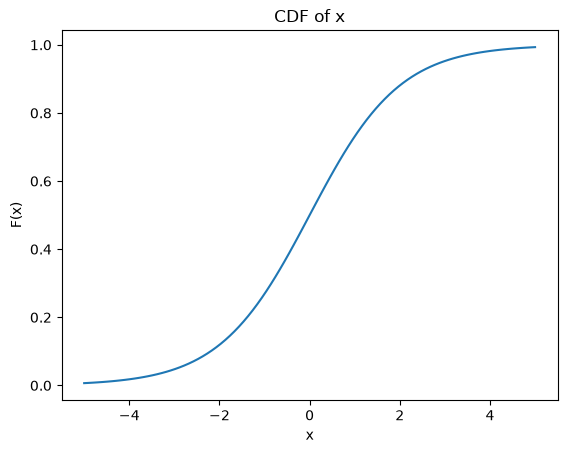

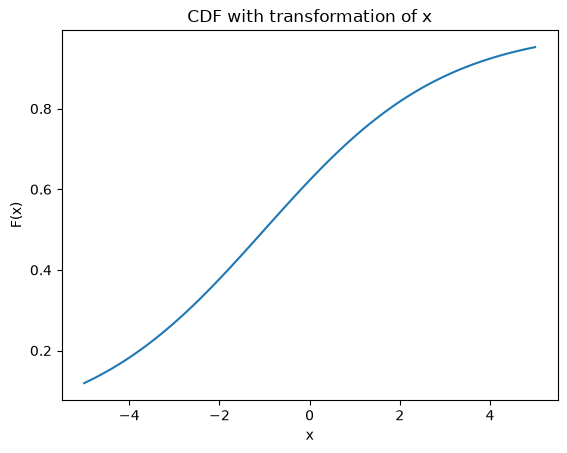

In [56]:
sns.lineplot(x=x, y=cdf)
plt.xlabel("x")
plt.ylabel("F(x)")
plt.title("CDF of x")
plt.show()

y = x.copy()
new_y = 1 / (1+np.exp(-((y+1)/2)))
sns.lineplot(x=x, y= new_y)
plt.xlabel("x")
plt.ylabel("F(x)")
plt.title("CDF with transformation of x")
plt.show()

![alt text](IMG_5673.jpeg)

### Q5.

![alt text](IMG_5676.jpeg)

### Q6.

In [63]:
data = pd.read_csv('./data/metabric.csv')

In [64]:
data.head(5)

,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Chemotherapy,Hormone Therapy,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,Overall Survival (Months),Overall Survival Status,Radio Therapy,TMB (nonsynonymous),Tumor Size,Tumor Stage
0,43.19,BREAST CONSERVING,Breast Cancer,NO,YES,0.0,2.0,4.020,84.633333,0:LIVING,YES,2.615035,10.0,1.0
1,48.87,MASTECTOMY,Breast Cancer,YES,YES,1.0,2.0,4.030,163.700000,1:DECEASED,NO,2.615035,15.0,2.0
2,47.68,MASTECTOMY,Breast Cancer,YES,YES,3.0,1.0,4.050,164.933333,0:LIVING,YES,1.307518,25.0,2.0
3,76.97,MASTECTOMY,Breast Cancer,YES,YES,8.0,2.0,6.080,41.366667,1:DECEASED,YES,2.615035,40.0,2.0
4,78.77,MASTECTOMY,Breast Cancer,NO,YES,0.0,4.0,4.062,7.800000,1:DECEASED,YES,5.230071,31.0,4.0


<Axes: xlabel='Overall Survival (Months)', ylabel='Proportion'>

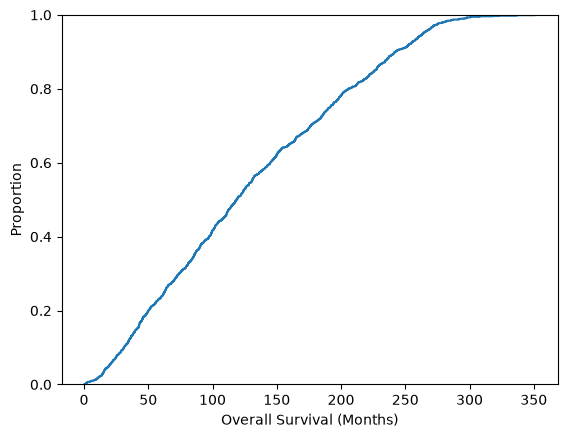

In [66]:
# part a
# Make an ECDF plot of Overall Survival (Months)
sns.ecdfplot( data=data, x='Overall Survival (Months)')

<Axes: xlabel='Overall Survival (Months)', ylabel='Proportion'>

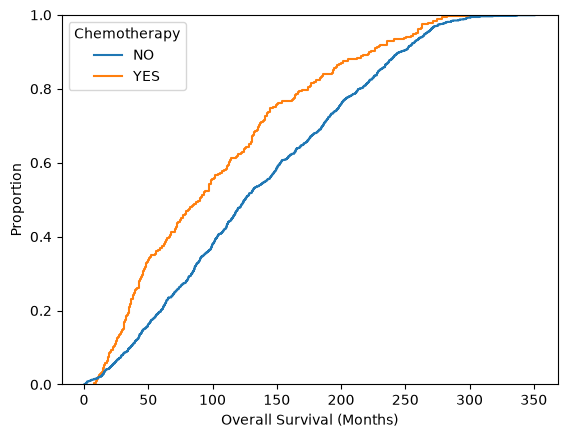

In [67]:
# part b: Make an ECDF plot of Overall Survival (Months), hued by Chemotherapy. Conditional on a
# patient receiving Chemotherapy, should we predict they will live a longer or shorter amount of time?
# Explain your answer clearly
sns.ecdfplot( data=data, x='Overall Survival (Months)', hue='Chemotherapy')

Looking at this graph, it appears that the group who received chemotherapy did not live as long as people who did not receive chemotherapy. However, the context of this situation matters when determining if the chemotherapy participants will live longer or shorter. If a patient is undergoing chemotherapy, their illness is already deemed terminal and the chemotherapy is trying to unltimately extend their life, so relative to how long that individual may have lived without chemo, the chemo could extend their life depending on the situation. This is not a guarantee, though. Compared to individuals who do not experience chemo, and most likely do not have a terminal illness, individuals undergoing cancer treatment would live for a shorter amount of time. Because of the different situations the 2 groups are in, comparing them is misleading. We should not predict that they will live a shorter or longer amount of time because it is relative to the situation.

part c. 

 Is chemotherapy an effective treatment? Explain your answer clearly.

Since the groups are in different situations, we can not confidently say that chemo is an effective treatment based off the ecdf alone. The non chemo group appears to live longer, but they most likely do not have a terminal illness that affects how long they will live. The chemo group most likely has a terminal illness they are combatting, and becuase of chemo, their lifespan may have been lengthened. However, since we do not have any other information from the ecdf, we can not confidently say that chemo is an effective treatment based off the ecdf plot.